# Garbage Image Classification

# Author:Amer Wahid

# Introduction

 Waste management systems increasingly rely on automated visual classification to sort recyclable and non-recyclable materials efficiently, reducing the reliance on manual sorting and improving recycling accuracy. This project builds an image classification model that automatically categorizes household waste into one of 12 classes: battery, biological, brown-glass, cardboard, clothes, green-glass, metal, paper, plastic, shoes, trash, and white-glass.

The dataset consists of 15,515 images drawn from the Garbage Classification dataset, with a notably imbalanced distribution across classes — ranging from 5,325 images for clothes down to 607 for brown-glass. This imbalance is addressed directly in the modeling pipeline rather than ignored.

The approach uses transfer learning with MobileNetV2, a lightweight convolutional network pretrained on ImageNet, chosen for its strong performance-to-compute ratio and suitability for practical deployment. Training follows a two-phase strategy:

Phase 1 — Feature extraction: the pretrained MobileNetV2 backbone is frozen, and only a new classification head (global average pooling, dropout, and a dense softmax layer) is trained on top of it.
Phase 2 — Fine-tuning: the later layers of the backbone are unfrozen and trained at a much lower learning rate, allowing the pretrained features to adapt more closely to the visual characteristics of waste images.

Data augmentation (random flips, rotation, zoom, and contrast) is applied during training to improve robustness, and class weighting is used to counteract the dataset's imbalance. The model's performance is evaluated using accuracy, a full classification report, and confusion matrix analysis to identify which categories are most often confused — insight that is directly relevant to where a real-world sorting system would need the most improvement.

# Import libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# Set the dataset path

In [2]:
DATASET_DIR = "/kaggle/input/datasets/mostafaabla/garbage-classification/garbage_classification"

In [3]:
print(os.listdir(DATASET_DIR))

['metal', 'white-glass', 'biological', 'paper', 'brown-glass', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'plastic', 'green-glass']


# Automatically detect the classes

In [4]:
classes = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

print("Number of classes:", len(classes))
print("Classes:")

for i, class_name in enumerate(classes):
    print(i, "->", class_name)

Number of classes: 12
Classes:
0 -> battery
1 -> biological
2 -> brown-glass
3 -> cardboard
4 -> clothes
5 -> green-glass
6 -> metal
7 -> paper
8 -> plastic
9 -> shoes
10 -> trash
11 -> white-glass


# Inspect class counts

In [5]:
class_counts = {}

for class_name in classes:

    class_path = os.path.join(DATASET_DIR, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    class_counts[class_name] = len(images)

class_counts = pd.Series(class_counts).sort_values(ascending=False)

print(class_counts)

clothes        5325
shoes          1977
paper          1050
biological      985
battery         945
cardboard       891
plastic         865
white-glass     775
metal           769
trash           697
green-glass     629
brown-glass     607
dtype: int64


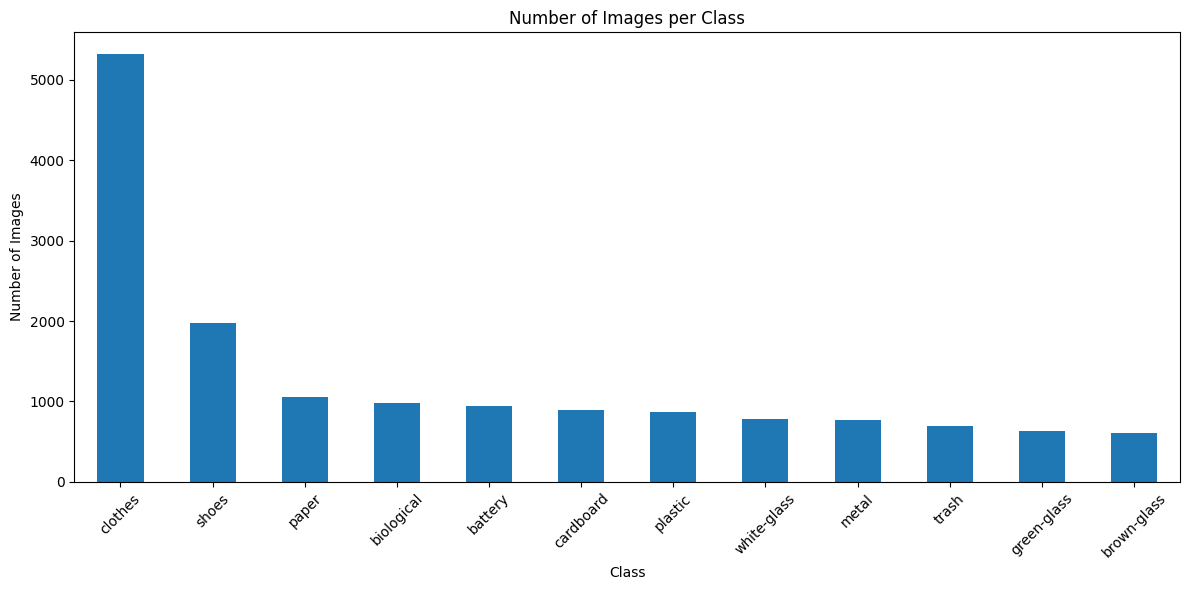

In [6]:
plt.figure(figsize=(12, 6))

class_counts.plot(kind="bar")

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# dataframe containing every image

In [7]:
data = []

for class_name in classes:

    class_path = os.path.join(DATASET_DIR, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):

            file_path = os.path.join(class_path, file_name)

            data.append({
                "filepath": file_path,
                "label": class_name
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
print(df.head())

Total images: 15515
                                            filepath    label
0  /kaggle/input/datasets/mostafaabla/garbage-cla...  battery
1  /kaggle/input/datasets/mostafaabla/garbage-cla...  battery
2  /kaggle/input/datasets/mostafaabla/garbage-cla...  battery
3  /kaggle/input/datasets/mostafaabla/garbage-cla...  battery
4  /kaggle/input/datasets/mostafaabla/garbage-cla...  battery


In [8]:
print(df["label"].value_counts())

label
clothes        5325
shoes          1977
paper          1050
biological      985
battery         945
cardboard       891
plastic         865
white-glass     775
metal           769
trash           697
green-glass     629
brown-glass     607
Name: count, dtype: int64


# Look at actual images

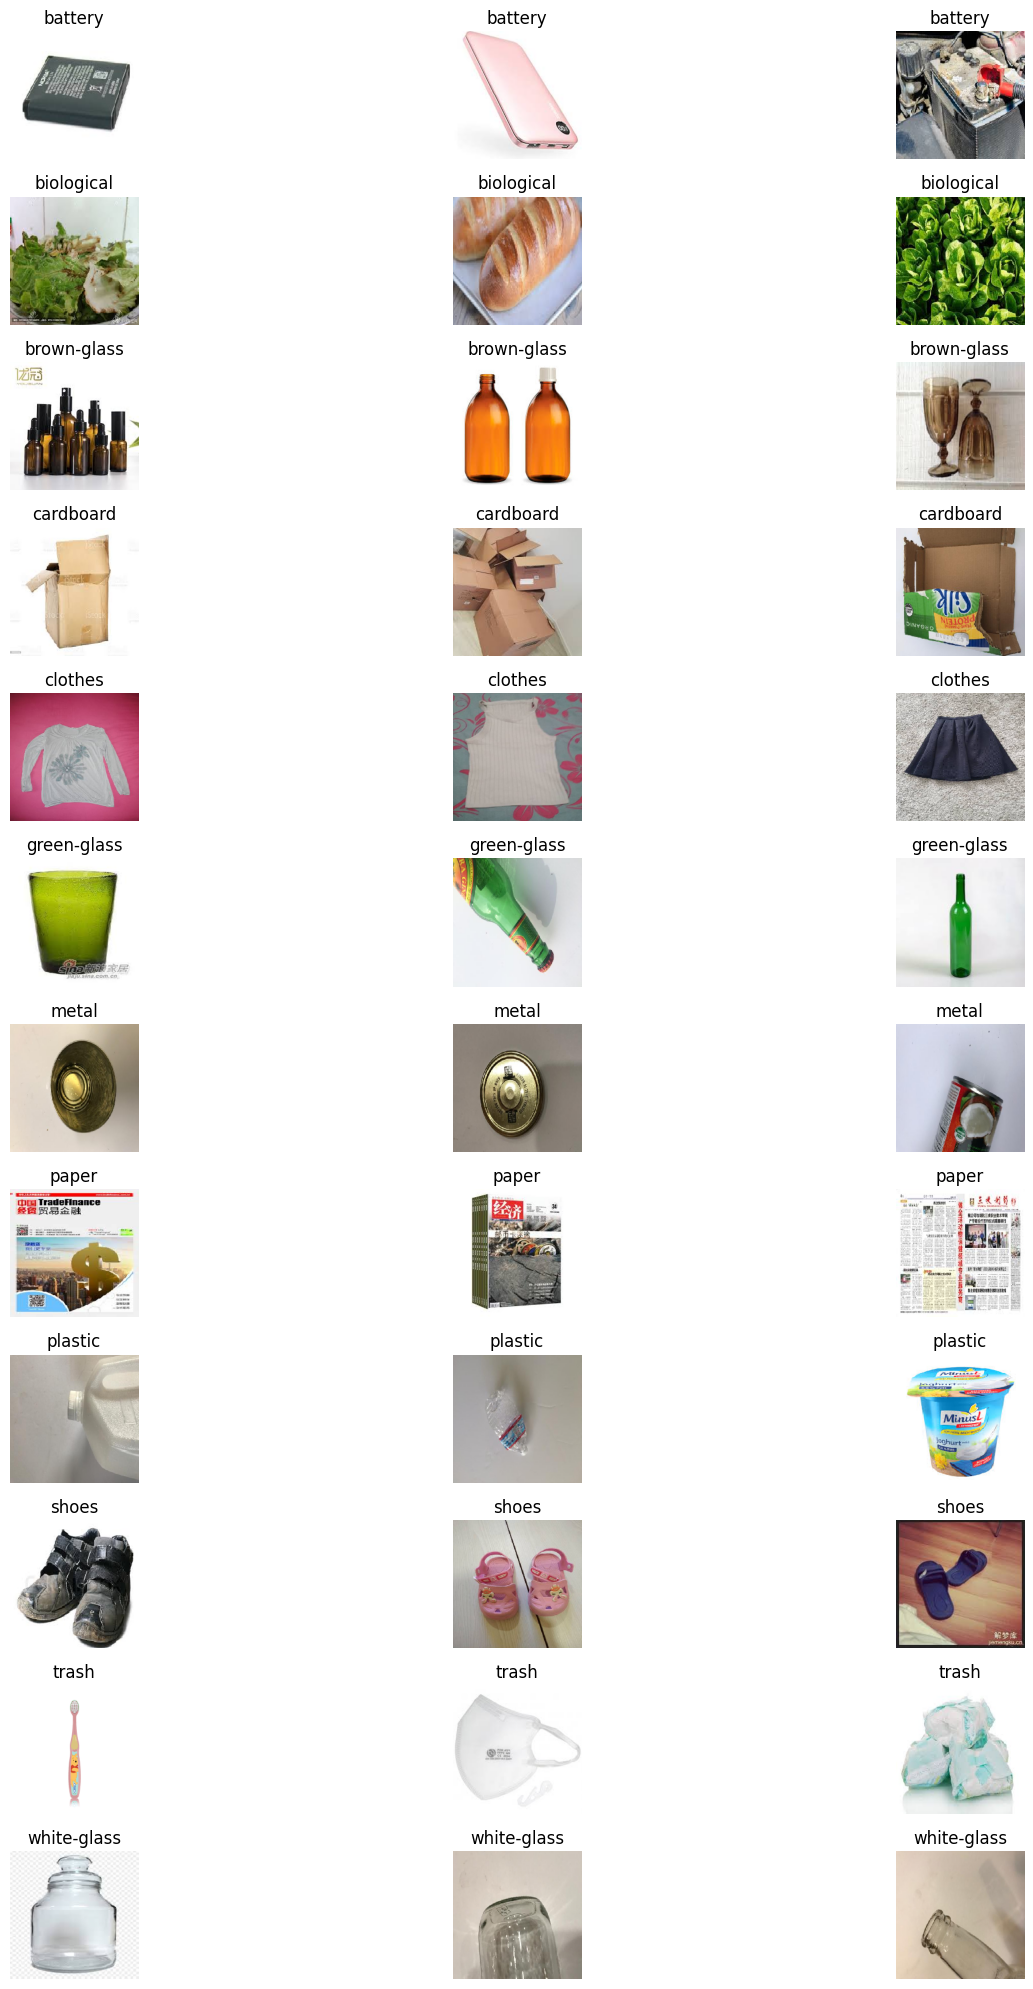

In [9]:
plt.figure(figsize=(16, 20))

for i, class_name in enumerate(classes):

    sample_images = df[df["label"] == class_name].sample(
        min(3, len(df[df["label"] == class_name])),
        random_state=42
    )

    for j, (_, row) in enumerate(sample_images.iterrows()):

        image = tf.keras.utils.load_img(
            row["filepath"],
            target_size=(224, 224)
        )

        image = tf.keras.utils.img_to_array(image)

        plt.subplot(len(classes), 3, i * 3 + j + 1)

        plt.imshow(image.astype("uint8"))
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

why 224×224 input, this gives us a manageable image size for training.

# Create Train / Validation / Test splits

In [10]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

In [11]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [12]:
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 10860
Validation: 2327
Testing: 2328


# Verify the split

In [13]:
print("TRAIN")
print(train_df["label"].value_counts())

print("\nVALIDATION")
print(val_df["label"].value_counts())

print("\nTEST")
print(test_df["label"].value_counts())

TRAIN
label
clothes        3727
shoes          1384
paper           735
biological      689
battery         661
cardboard       624
plastic         606
white-glass     543
metal           538
trash           488
green-glass     440
brown-glass     425
Name: count, dtype: int64

VALIDATION
label
clothes        799
shoes          296
paper          157
biological     148
battery        142
cardboard      133
plastic        129
white-glass    116
metal          116
trash          105
green-glass     95
brown-glass     91
Name: count, dtype: int64

TEST
label
clothes        799
shoes          297
paper          158
biological     148
battery        142
cardboard      134
plastic        130
white-glass    116
metal          115
trash          104
green-glass     94
brown-glass     91
Name: count, dtype: int64


# Convert labels to numbers

In [14]:
class_to_index = {
    class_name: index
    for index, class_name in enumerate(classes)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

print(class_to_index)

{'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}


TensorFlow needs numerical labels.

In [15]:
train_df["label_id"] = train_df["label"].map(class_to_index)
val_df["label_id"] = val_df["label"].map(class_to_index)
test_df["label_id"] = test_df["label"].map(class_to_index)

# Imballanced data

In [16]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_id"]),
    y=train_df["label_id"]
)

class_weights = {
    i: weight
    for i, weight in enumerate(class_weights_array)
}

print(class_weights)

{0: np.float64(1.3691376701966718), 1: np.float64(1.3134978229317853), 2: np.float64(2.1294117647058823), 3: np.float64(1.4503205128205128), 4: np.float64(0.24282264555943117), 5: np.float64(2.0568181818181817), 6: np.float64(1.6821561338289963), 7: np.float64(1.2312925170068028), 8: np.float64(1.4933993399339933), 9: np.float64(0.6539017341040463), 10: np.float64(1.8545081967213115), 11: np.float64(1.6666666666666667)}


# Create TensorFlow datasets

In [17]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(classes)

In [18]:
def create_dataset(dataframe, shuffle=False):

    paths = dataframe["filepath"].values
    labels = dataframe["label_id"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    def load_image(path, label):

        image = tf.io.read_file(path)

        image = tf.image.decode_image(
            image,
            channels=3,
            expand_animations=False
        )

        image = tf.image.resize(
            image,
            IMG_SIZE
        )

        image = tf.cast(image, tf.float32)

        image = preprocess_input(image)

        return image, label

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=1000,
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

## Create the datasets

In [19]:
train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

I0000 00:00:1789592912.541547      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789592912.544809      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Data augmentation


In [20]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

This helps the model handle different orientations and positions of garbage.

# Build MobileNetV2

In [21]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


include_top=False means:

Remove MobileNetV2's original ImageNet classification layer.

# Freeze the backbone

In [22]:
base_model.trainable = False

The pretrained CNN will not change.

It will extract useful visual features.

# Add our classification head

In [23]:
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = models.Model(
    inputs,
    outputs
)

In [24]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │        15,372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273,356 (8.67 MB)

 Trainable params: 15,372 (60.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Compile Phase 1

In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks

In [26]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )
]

# Phase 1 training

In [27]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 48s 104ms/step - accuracy: 0.7122 - loss: 1.0873 - val_accuracy: 0.9012 - val_loss: 0.3472 - learning_rate: 0.0010
Epoch 2/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.8243 - loss: 0.6268 - val_accuracy: 0.9119 - val_loss: 0.2917 - learning_rate: 0.0010
Epoch 3/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.8491 - loss: 0.5442 - val_accuracy: 0.9119 - val_loss: 0.2820 - learning_rate: 0.0010
Epoch 4/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.8584 - loss: 0.5041 - val_accuracy: 0.9214 - val_loss: 0.2600 - learning_rate: 0.0010
Epoch 5/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.8608 - loss: 0.4844 - val_accuracy: 0.9205 - val_loss: 0.2673 - learning_rate: 0.0010
Epoch 6/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.8695 - loss: 0.4599 - val_accuracy: 0.9214 - val_loss: 0.2449 - learning_rate: 0.0010
Epoch 7/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.8739 - 

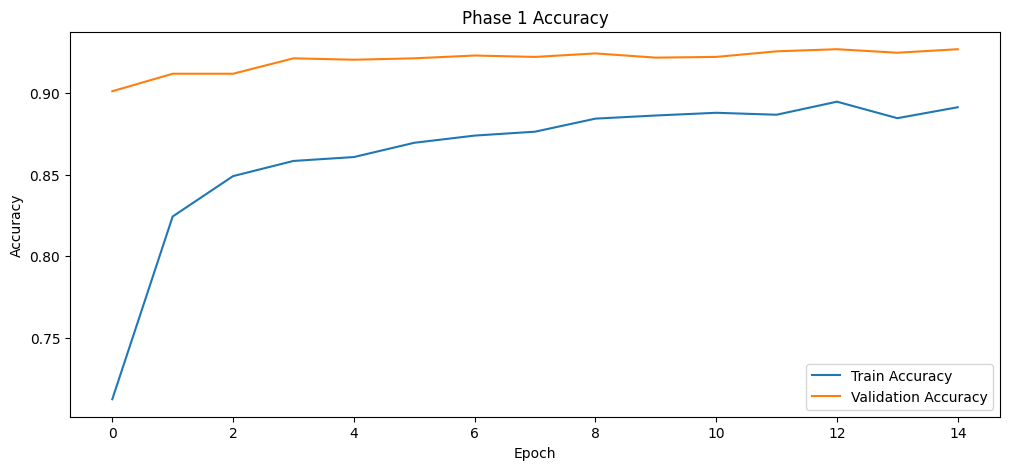

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(history1.history["accuracy"], label="Train Accuracy")
plt.plot(history1.history["val_accuracy"], label="Validation Accuracy")

plt.title("Phase 1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

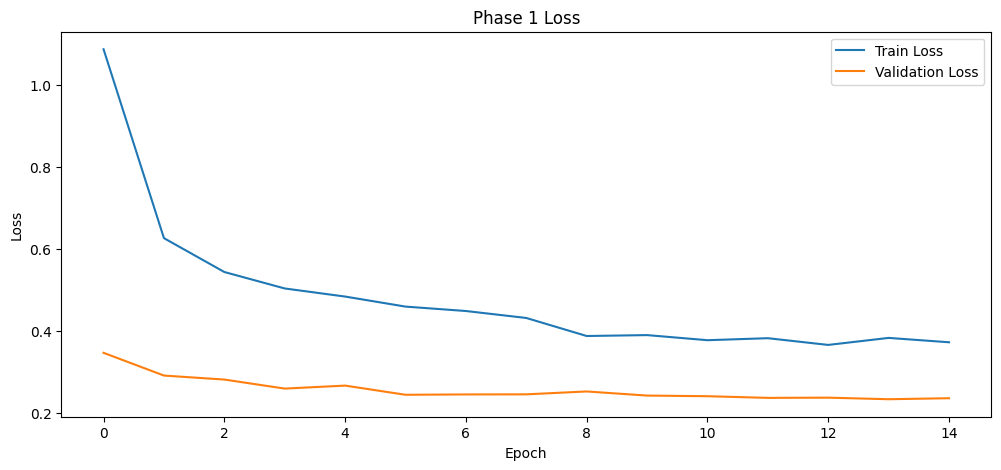

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(history1.history["loss"], label="Train Loss")
plt.plot(history1.history["val_loss"], label="Validation Loss")

plt.title("Phase 1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Phase 1 evaluation

In [30]:
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9248 - loss: 0.2341
Validation Loss: 0.2340671420097351
Validation Accuracy: 0.9247958660125732


# Phase 2: Fine-tuning

In [31]:
base_model.trainable = True

In [32]:
for layer in base_model.layers[:-40]:
    layer.trainable = False

freeze the earlier layers

In [33]:
trainable_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print("Number of trainable layers:", len(trainable_layers))
print(trainable_layers)

Number of trainable layers: 40
['block_12_project_BN', 'block_12_add', 'block_13_expand', 'block_13_expand_BN', 'block_13_expand_relu', 'block_13_pad', 'block_13_depthwise', 'block_13_depthwise_BN', 'block_13_depthwise_relu', 'block_13_project', 'block_13_project_BN', 'block_14_expand', 'block_14_expand_BN', 'block_14_expand_relu', 'block_14_depthwise', 'block_14_depthwise_BN', 'block_14_depthwise_relu', 'block_14_project', 'block_14_project_BN', 'block_14_add', 'block_15_expand', 'block_15_expand_BN', 'block_15_expand_relu', 'block_15_depthwise', 'block_15_depthwise_BN', 'block_15_depthwise_relu', 'block_15_project', 'block_15_project_BN', 'block_15_add', 'block_16_expand', 'block_16_expand_BN', 'block_16_expand_relu', 'block_16_depthwise', 'block_16_depthwise_BN', 'block_16_depthwise_relu', 'block_16_project', 'block_16_project_BN', 'Conv_1', 'Conv_1_bn', 'out_relu']


# Compile again with a low learning rate

In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Fine-tune

In [35]:
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 50s 105ms/step - accuracy: 0.8185 - loss: 0.6119 - val_accuracy: 0.9222 - val_loss: 0.2429 - learning_rate: 1.0000e-05
Epoch 2/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 34s 98ms/step - accuracy: 0.8416 - loss: 0.4967 - val_accuracy: 0.9196 - val_loss: 0.2488 - learning_rate: 1.0000e-05
Epoch 3/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step - accuracy: 0.8539 - loss: 0.4529 - val_accuracy: 0.9205 - val_loss: 0.2514 - learning_rate: 2.0000e-06
Epoch 4/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step - accuracy: 0.8611 - loss: 0.4417 - val_accuracy: 0.9183 - val_loss: 0.2554 - learning_rate: 2.0000e-06
Epoch 5/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 34s 98ms/step - accuracy: 0.8644 - loss: 0.4302 - val_accuracy: 0.9175 - val_loss: 0.2620 - learning_rate: 4.0000e-07


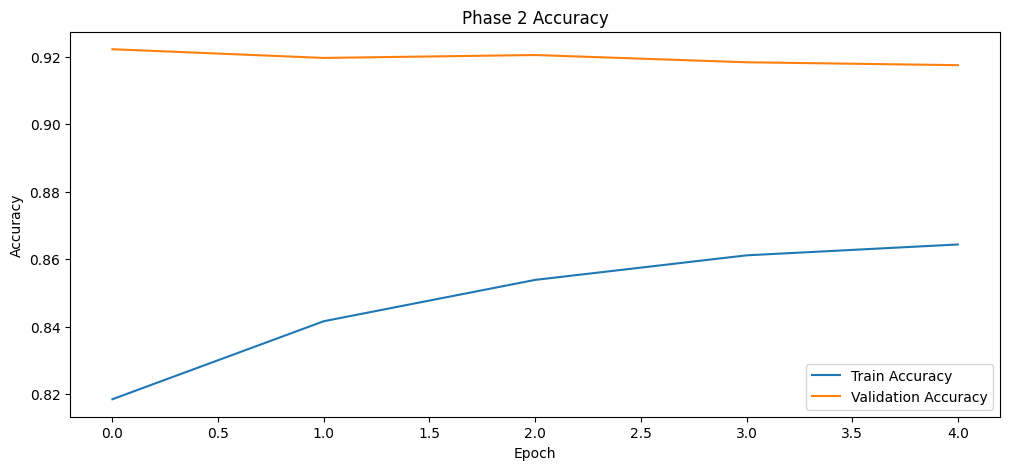

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(history2.history["accuracy"], label="Train Accuracy")
plt.plot(history2.history["val_accuracy"], label="Validation Accuracy")

plt.title("Phase 2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

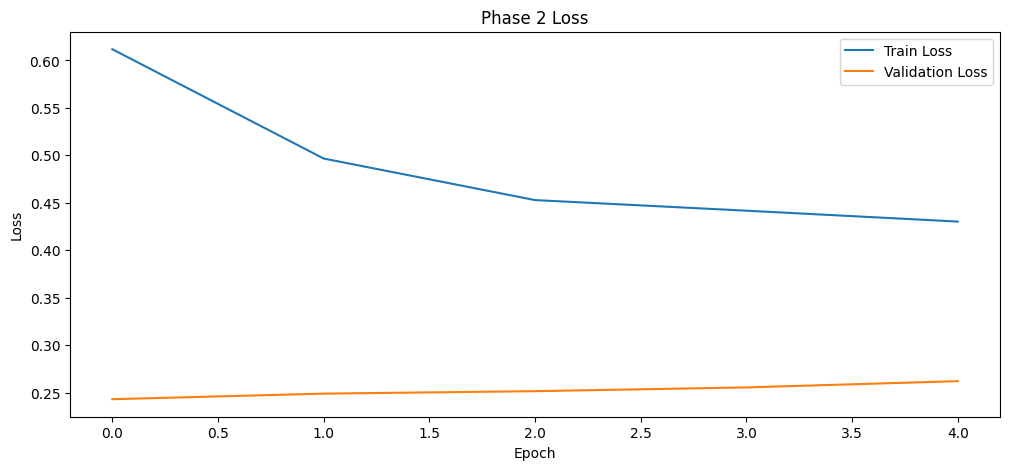

In [37]:
plt.figure(figsize=(12, 5))

plt.plot(history2.history["loss"], label="Train Loss")
plt.plot(history2.history["val_loss"], label="Validation Loss")

plt.title("Phase 2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# first final evaluation

In [38]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.9197 - loss: 0.2587
Test Loss: 0.2587009072303772
Test Accuracy: 0.9196735620498657


# Generate predictions

In [39]:
y_true = test_df["label_id"].values

y_prob = model.predict(test_ds)

y_pred = np.argmax(y_prob, axis=1)

73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step


In [40]:
print("Number of true labels:", len(y_true))
print("Number of predictions:", len(y_pred))

Number of true labels: 2328
Number of predictions: 2328


# Classification Report

In [41]:
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)

print(report)

              precision    recall  f1-score   support

     battery     0.8993    0.9437    0.9210       142
  biological     0.9714    0.9189    0.9444       148
 brown-glass     0.9429    0.7253    0.8199        91
   cardboard     0.9173    0.9104    0.9139       134
     clothes     0.9949    0.9700    0.9823       799
 green-glass     0.9149    0.9149    0.9149        94
       metal     0.6828    0.8609    0.7615       115
       paper     0.9026    0.8797    0.8910       158
     plastic     0.8462    0.7615    0.8016       130
       shoes     0.9433    0.9529    0.9481       297
       trash     0.8430    0.9808    0.9067       104
 white-glass     0.7937    0.8621    0.8264       116

    accuracy                         0.9197      2328
   macro avg     0.8877    0.8901    0.8860      2328
weighted avg     0.9245    0.9197    0.9204      2328



# Confusion Matrix

In [42]:
cm = confusion_matrix(
    y_true,
    y_pred
)

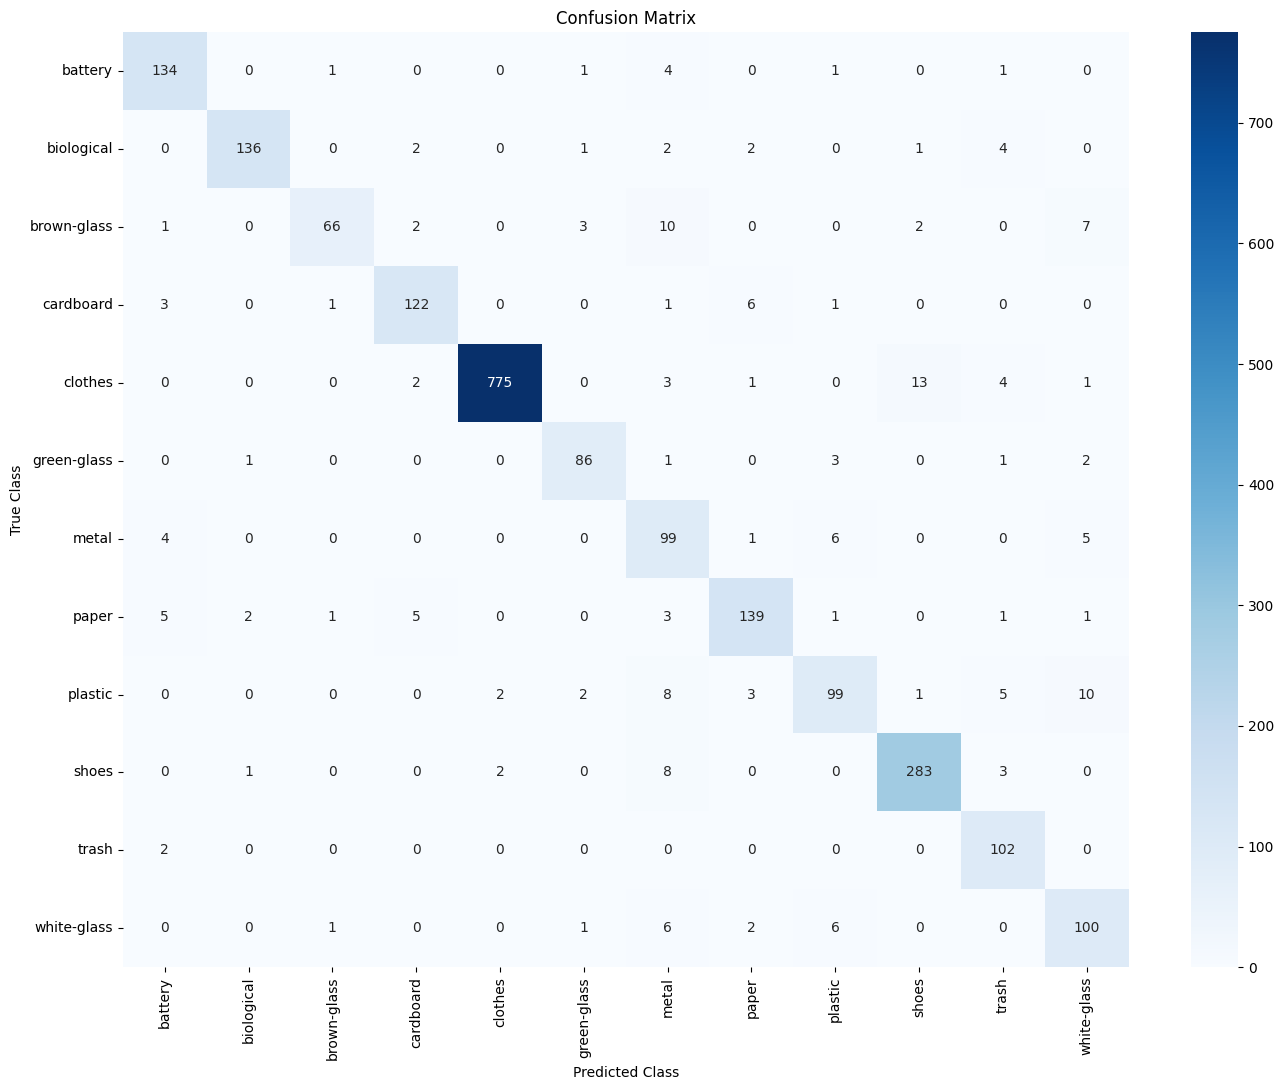

In [43]:
plt.figure(figsize=(14, 11))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

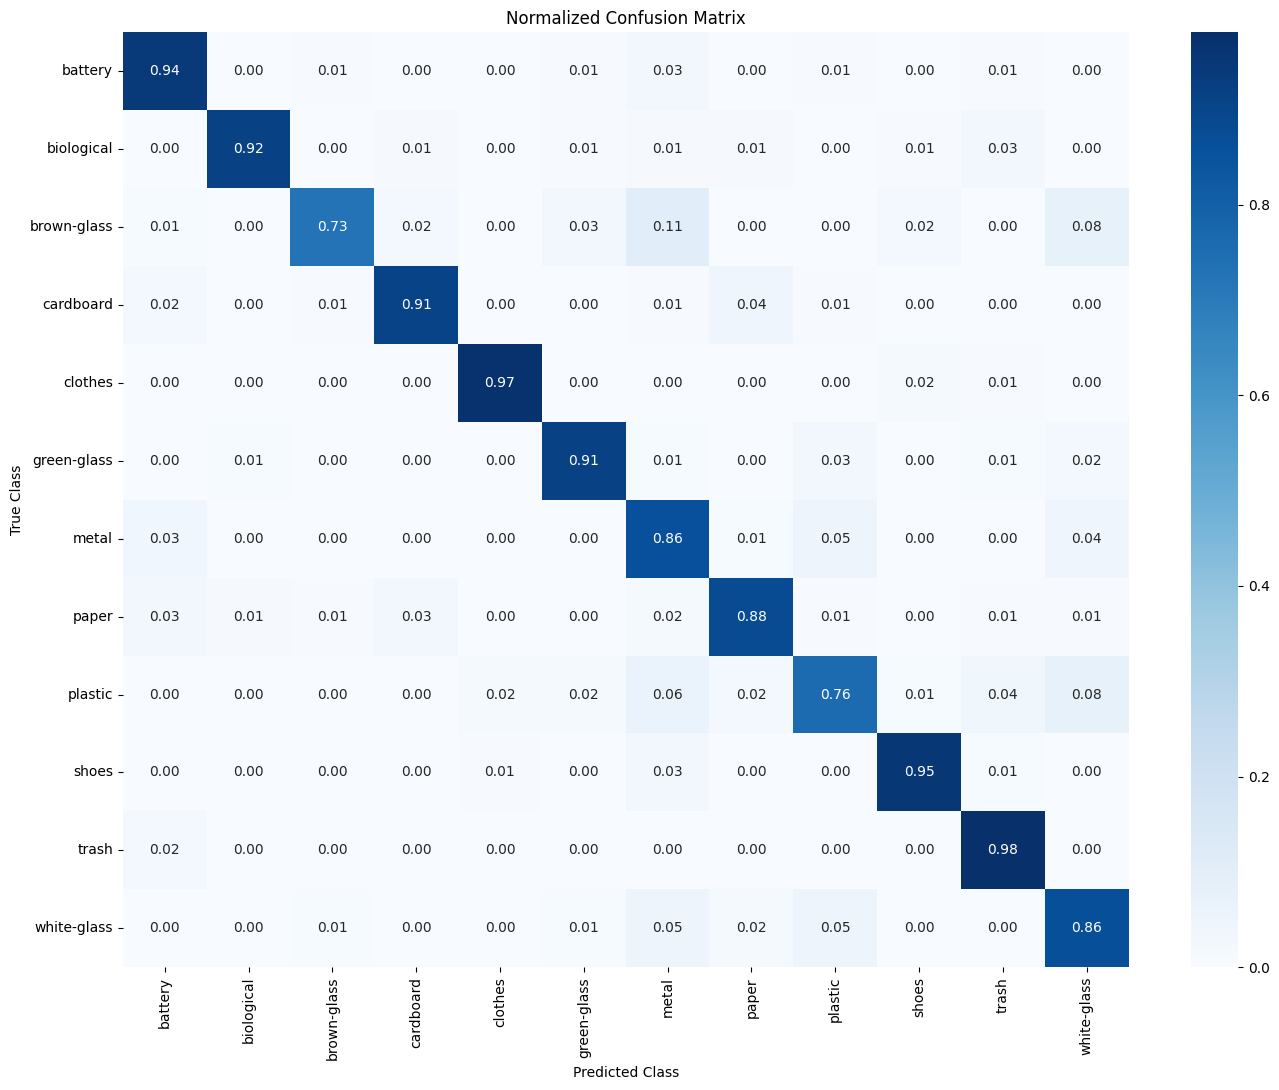

In [44]:
cm_normalized = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

# classes the model confuses most 

In [45]:
cm_no_diag = cm.copy()

np.fill_diagonal(cm_no_diag, 0)

confused_pairs = []

for i in range(len(classes)):

    for j in range(len(classes)):

        if cm_no_diag[i, j] > 0:

            confused_pairs.append({
                "Actual": classes[i],
                "Predicted": classes[j],
                "Count": cm_no_diag[i, j]
            })

confused_pairs = pd.DataFrame(confused_pairs)

confused_pairs = confused_pairs.sort_values(
    "Count",
    ascending=False
)

print(confused_pairs.head(15))

         Actual    Predicted  Count
25      clothes        shoes     13
14  brown-glass        metal     10
51      plastic  white-glass     10
47      plastic        metal      8
54        shoes        metal      8
16  brown-glass  white-glass      7
35        metal      plastic      6
20    cardboard        paper      6
61  white-glass      plastic      6
59  white-glass        metal      6
36        metal  white-glass      5
37        paper      battery      5
40        paper    cardboard      5
50      plastic        trash      5
26      clothes        trash      4


# Look at wrong predictions

In [46]:
test_results = test_df.copy()

test_results["true_class"] = test_results["label_id"].map(index_to_class)
test_results["predicted_id"] = y_pred
test_results["predicted_class"] = test_results["predicted_id"].map(index_to_class)

test_results["confidence"] = np.max(
    y_prob,
    axis=1
)

In [47]:
wrong_predictions = test_results[
    test_results["label_id"] != test_results["predicted_id"]
]

print("Wrong predictions:", len(wrong_predictions))

Wrong predictions: 187


# Display wrong predictions

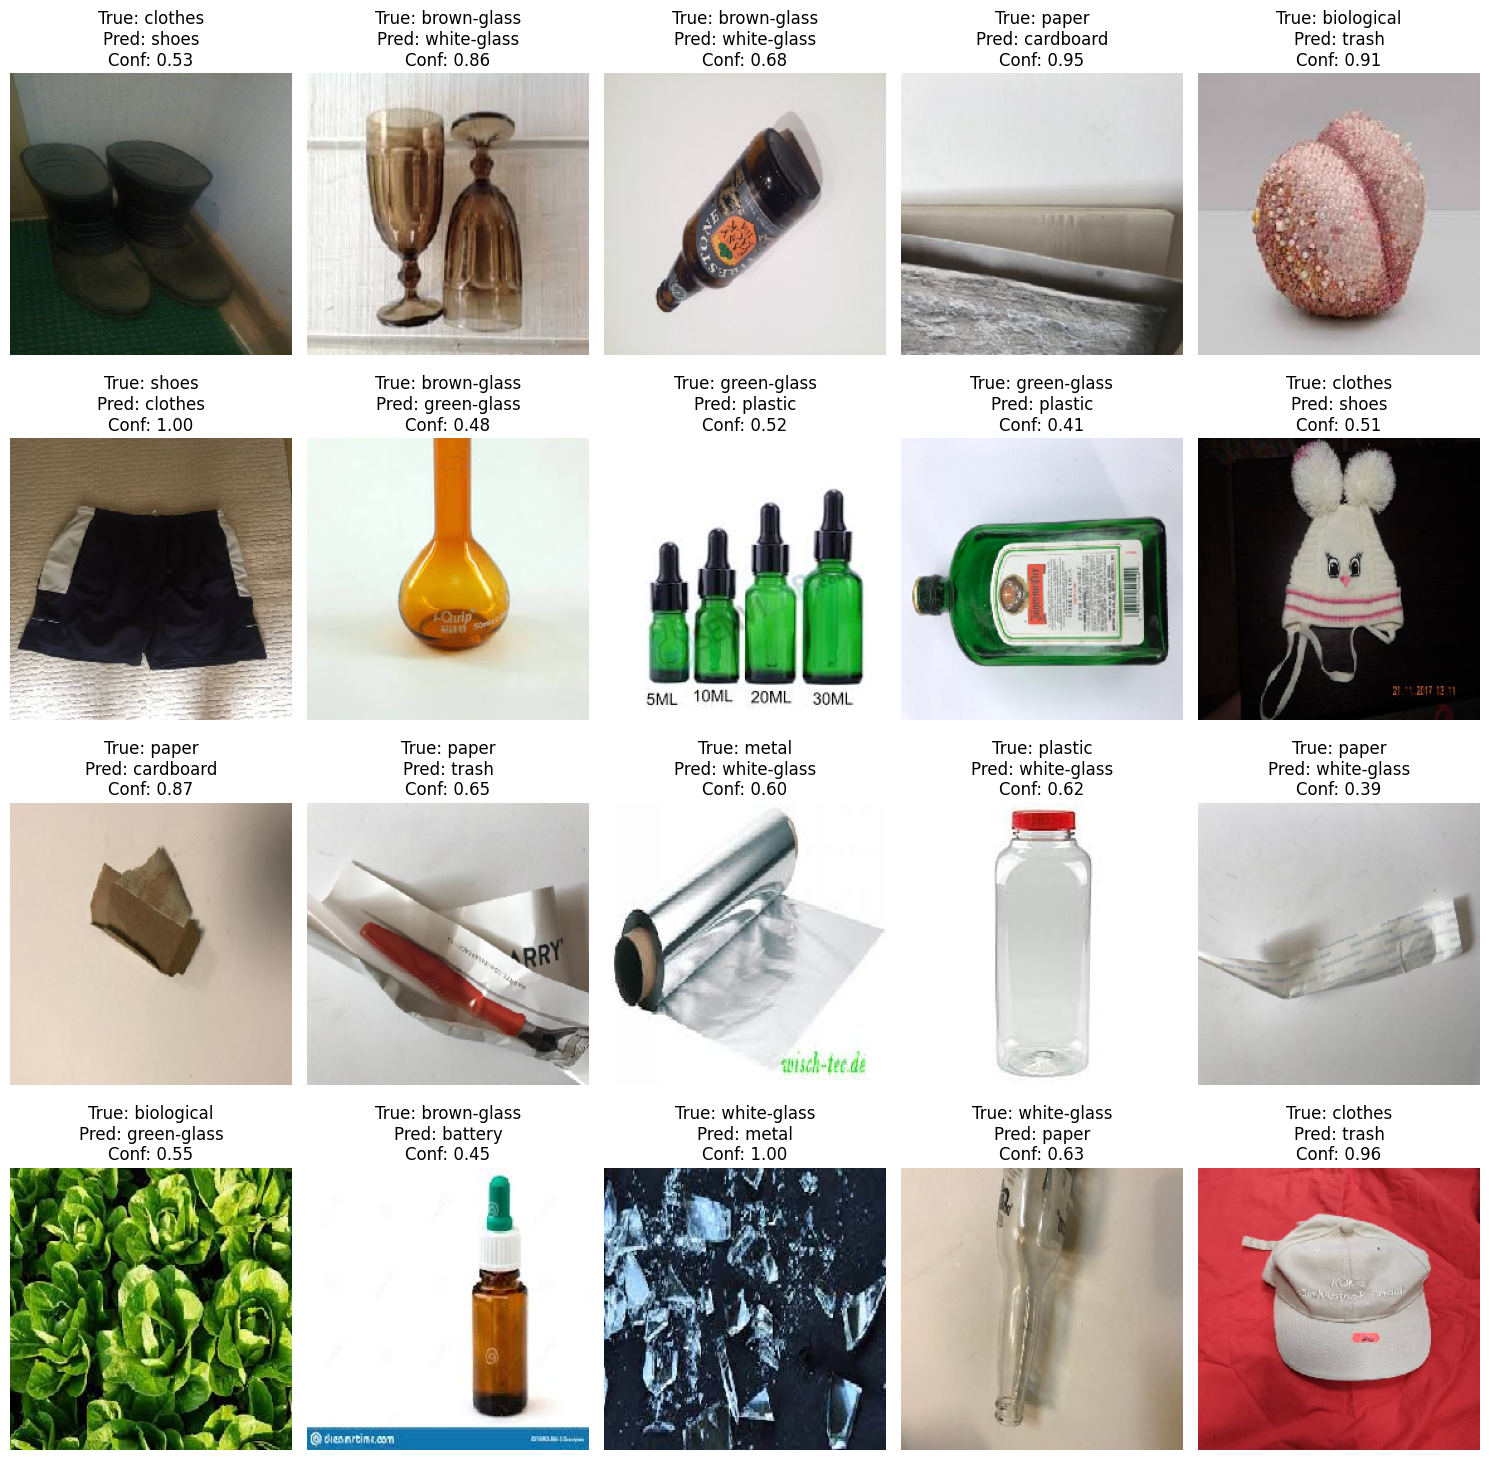

In [48]:
sample_wrong = wrong_predictions.sample(
    min(20, len(wrong_predictions)),
    random_state=42
)

plt.figure(figsize=(15, 15))

for i, (_, row) in enumerate(sample_wrong.iterrows()):

    image = tf.keras.utils.load_img(
        row["filepath"],
        target_size=IMG_SIZE
    )

    plt.subplot(4, 5, i + 1)

    plt.imshow(image)

    plt.title(
        f"True: {row['true_class']}\n"
        f"Pred: {row['predicted_class']}\n"
        f"Conf: {row['confidence']:.2f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Compare Phase 1 vs Phase 2

In [49]:
phase1_best_val = max(history1.history["val_accuracy"])
phase2_best_val = max(history2.history["val_accuracy"])

print("Phase 1 Best Validation Accuracy:", phase1_best_val)
print("Phase 2 Best Validation Accuracy:", phase2_best_val)

Phase 1 Best Validation Accuracy: 0.9269445538520813
Phase 2 Best Validation Accuracy: 0.9222174286842346


In [50]:
print(
    "Improvement:",
    phase2_best_val - phase1_best_val
)

Improvement: -0.00472712516784668


During Phase 1, the pretrained MobileNetV2 backbone was frozen and only the new classification head was trained. During Phase 2, the later backbone layers were unfrozen and fine-tuned with a smaller learning rate, allowing the pretrained features to adapt to the visual characteristics of household waste.

# Save the model

In [51]:
model.save("garbage_classifier_mobilenetv2.keras")

# Conclusion

This project built a 12-class garbage/waste image classifier using transfer learning with MobileNetV2, trained on a highly imbalanced dataset (607–5,325 images per class) via stratified splits and class-weighted loss.

Results: The model reached 91.97% test accuracy (weighted F1 = 0.9204, macro F1 = 0.8860), with 187 of 2,328 test images misclassified. Performance was strongest on visually distinct, well-represented classes — clothes (F1 = 0.9823), shoes (0.9481), and biological (0.9444) — and weakest on classes that are visually similar to one another or underrepresented: metal (F1 = 0.7615), brown-glass (0.8199), and white-glass (0.8264).

Error patterns: The confusion matrix and confused-pairs analysis show the model's mistakes are concentrated in a few intuitive, visually-grounded confusions rather than being random: clothes↔shoes, brown-glass↔metal, plastic↔white-glass/metal, and cardboard↔paper. These are exactly the class pairs a human might also confuse from a photo (reflective/metallic surfaces, similarly-colored glass, and folded fabric items), suggesting the errors stem from genuine visual ambiguity in the data rather than a modeling flaw.

Two-phase training: Fine-tuning the last 40 layers of MobileNetV2 (Phase 2) did not improve on the frozen-backbone baseline (Phase 1) — validation accuracy dropped slightly, from 92.69% to 92.22%. This suggests the pretrained ImageNet features were already well-suited to this task, and further fine-tuning at this scale mainly risked overfitting rather than adding useful signal. A smaller fine-tuning learning rate, fewer unfrozen layers, or more training data per minority class would likely be needed to make Phase 2 pay off.

Overall: the model generalizes well (test accuracy tracks validation accuracy closely, indicating no serious overfitting) and is production-viable for coarse waste sorting, though classes involving glass/metal/plastic would benefit from more training data or finer-grained features before deployment in a real recycling pipeline.